In [9]:
import warnings
for warn in [UserWarning, FutureWarning]: warnings.filterwarnings("ignore", category = warn)

import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import polars as pl
import pandas as pd
import yfinance as yf
import sklearn
import networkx as nx
import jupyterlab as jlab
import ipywidgets
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from mpl_toolkits.mplot3d import Axes3D

## Процесс обучения LSTM

[*********************100%***********************]  1 of 1 completed


Epoch 0, Loss: 0.025807
Epoch 10, Loss: 0.014266
Epoch 20, Loss: 0.005361
Epoch 30, Loss: 0.004725
Epoch 40, Loss: 0.003217
Epoch 50, Loss: 0.003684
Epoch 60, Loss: 0.002761
Epoch 70, Loss: 0.003039
Epoch 80, Loss: 0.002422
Epoch 90, Loss: 0.002039
Epoch 100, Loss: 0.002045
Epoch 110, Loss: 0.001683


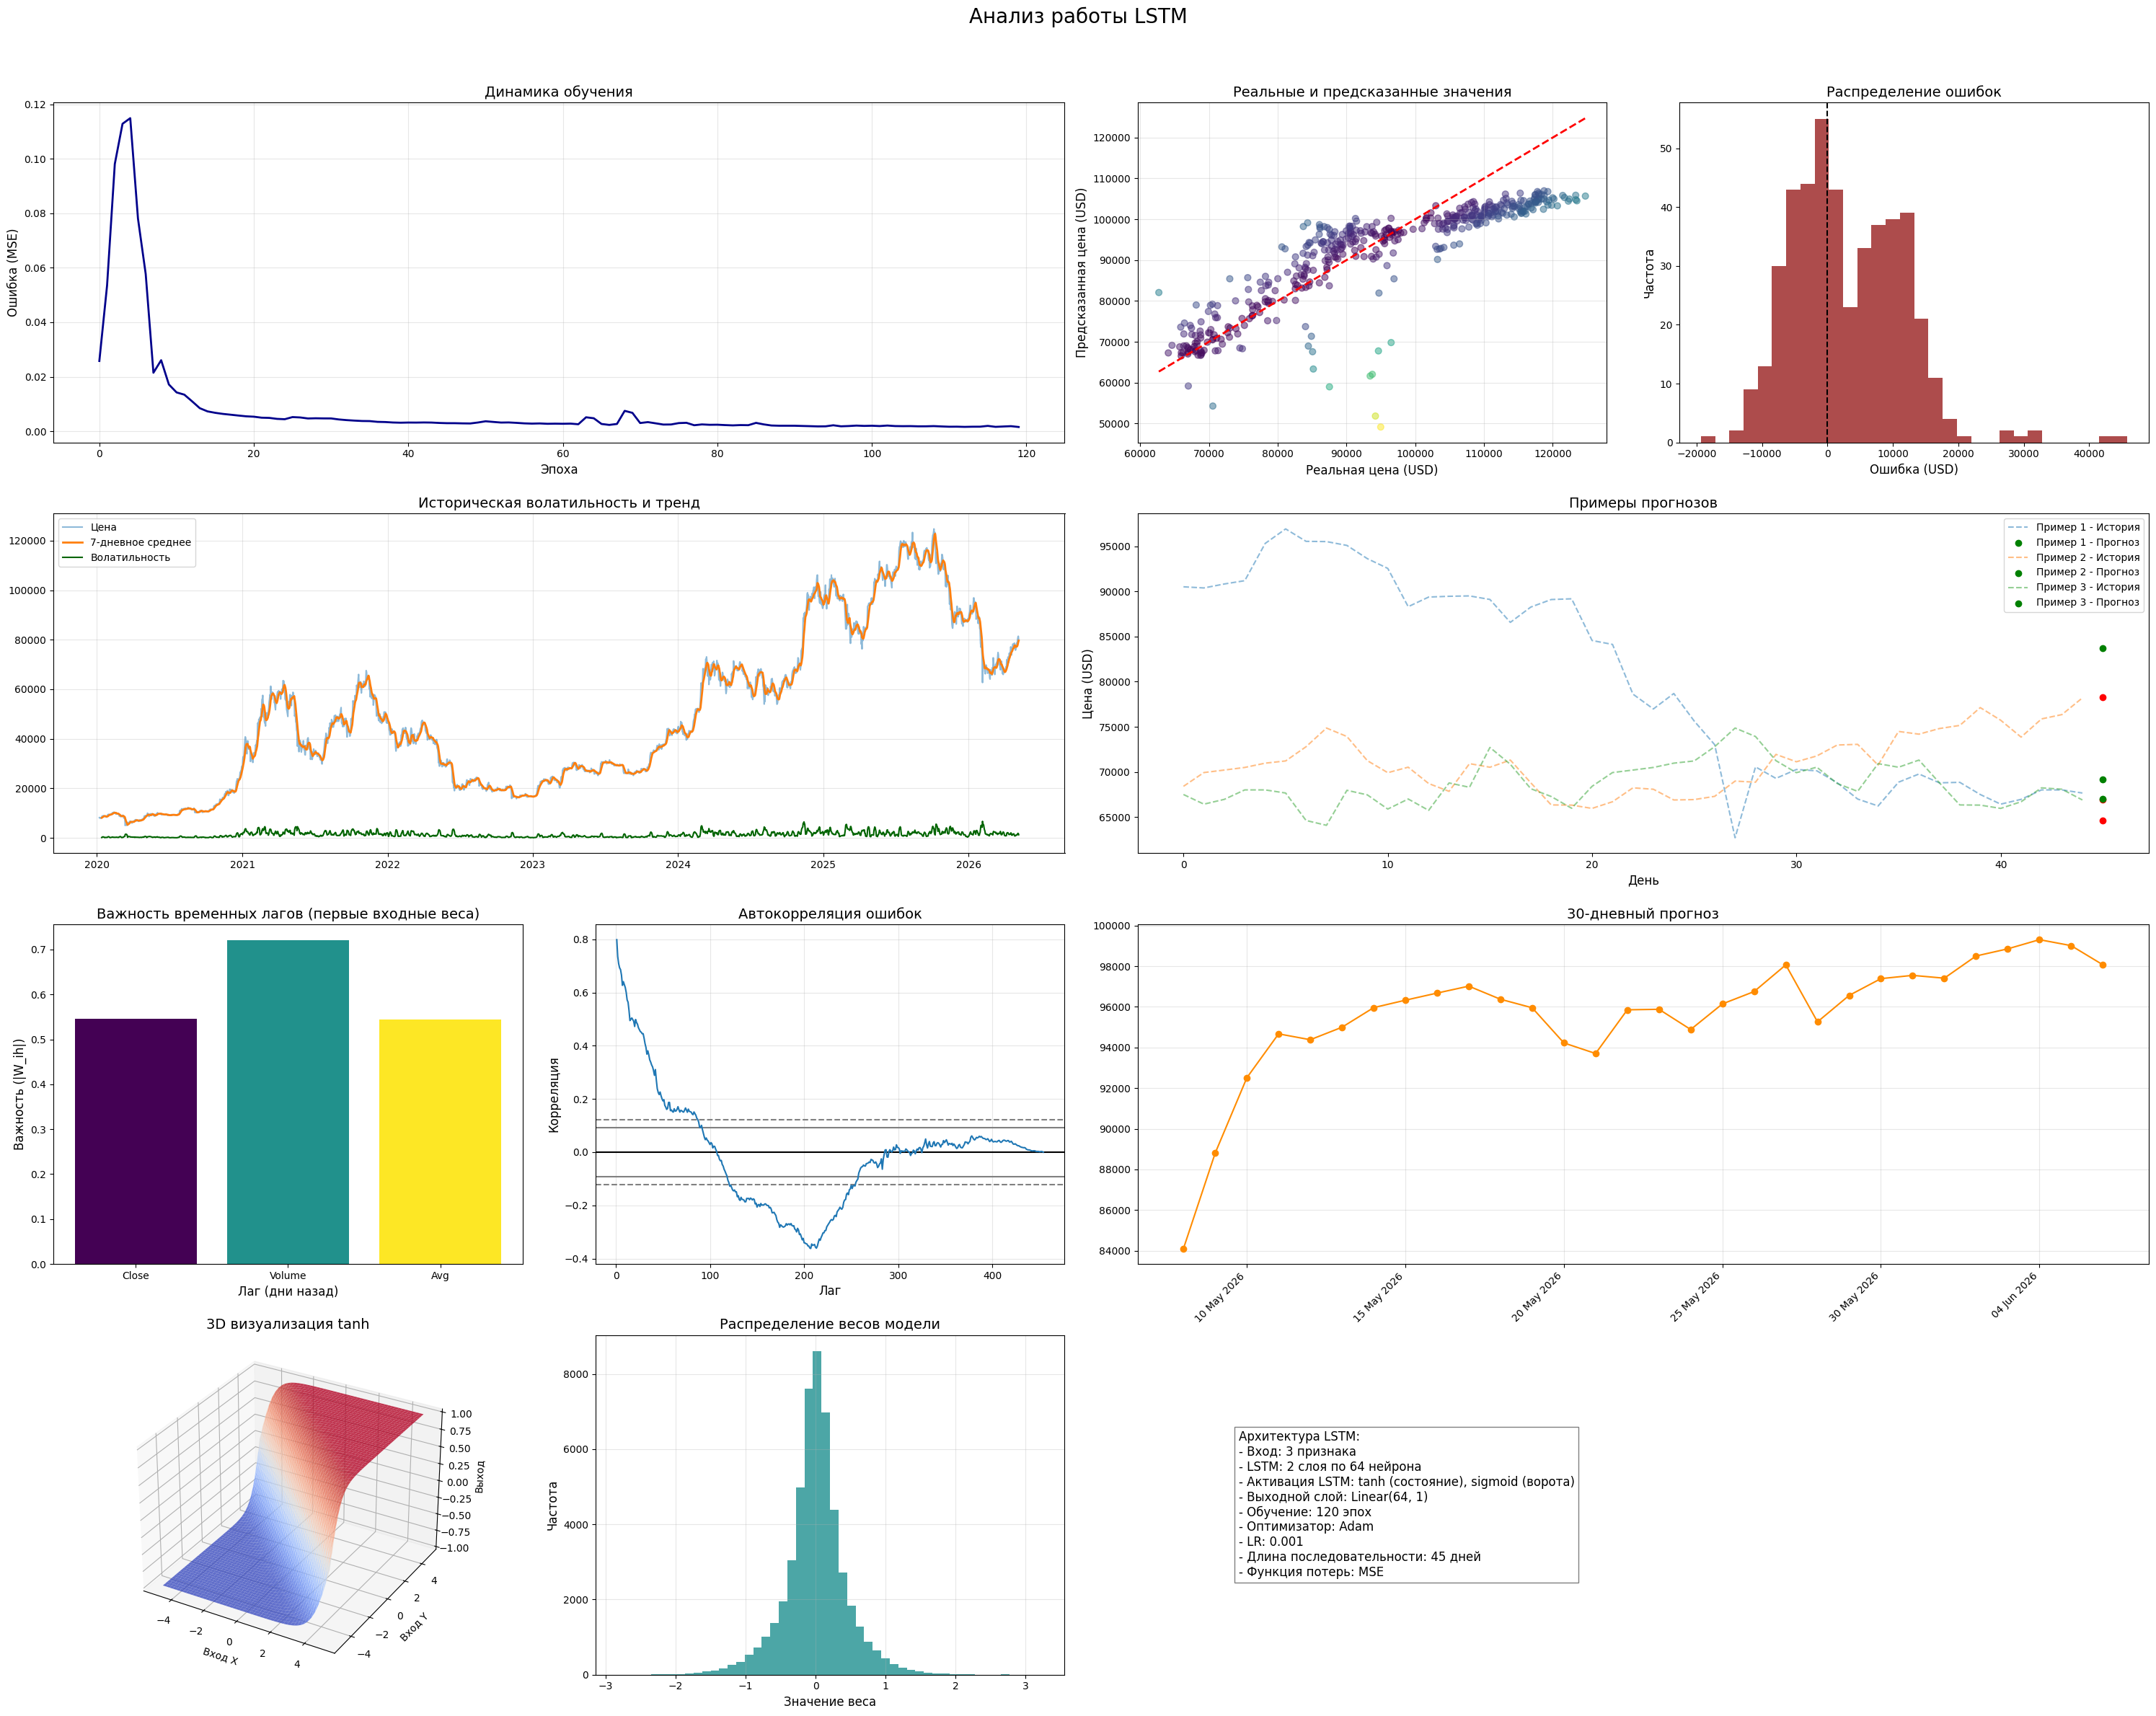

In [24]:
# Загрузка данных
ticker = "BTC-USD"
data = yf.download(ticker, start = "2020-01-01", end=pd.Timestamp.now().strftime("%Y-%m-%d"))
data["Avg"] = data["Close"].rolling(window=7).mean()
data.dropna(inplace=True)

data = data[["Close", "Volume", "Avg"]]

# Нормализация данных
scaler1 = StandardScaler()
scaled_data = scaler1.fit_transform(data)

target_scaler = StandardScaler()
scaled_target = target_scaler.fit_transform(data[["Close"]])

# Создание последовательностей
def create_sequences(data,target, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(target[i+seq_length])
    return torch.FloatTensor(X), torch.FloatTensor(y)

seq_length = 45
X, y = create_sequences(scaled_data, scaled_target, seq_length)

# Разделение данных
train_size = int(0.8 * len(X))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Определение LSTM модели
class BitcoinLSTM(nn.Module):
    def __init__(self, input_size = 1, hidden_size = 64, num_layers = 2):
        super(BitcoinLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.lstm = nn.LSTM(
            input_size = input_size,
            hidden_size = hidden_size,
            num_layers = num_layers,
            batch_first = True
        )
        self.fc1 = nn.Linear(hidden_size, 1)
        
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).requires_grad_()
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).requires_grad_()
        out, (hn, cn) = self.lstm(x, (h0.detach(), c0.detach()))
        out = self.fc1(out[:, -1, :])
        return out

# Инициализация модели
input_size=data.shape[1]
model = BitcoinLSTM(input_size=input_size)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001)

# Обучение модели
num_epochs = 120
train_loss = []

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    
    for i in range(len(X_train)):
        inputs = X_train[i].unsqueeze(0)
        target = y_train[i].unsqueeze(0)
        
        optimizer.zero_grad()
        output = model(inputs)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    avg_loss = total_loss / len(X_train)
    train_loss.append(avg_loss)
    
    if epoch % 10 == 0:
        print(f'Epoch {epoch}, Loss: {avg_loss:.6f}')

# Прогнозирование
def forecast(model, sequence, days=30):
    current_seq = sequence.squeeze(0)
    predictions = []

    with torch.no_grad():
        for _ in range(days):
            pred = model(current_seq.unsqueeze(0))
            predictions.append(pred.item())

            new_row = current_seq[-1].clone()
            new_row[0] = pred.item()
            current_seq = torch.cat((current_seq[1:], new_row.unsqueeze(0)), dim=0)

    return predictions

# Генерация прогноза
last_sequence = scaled_data[-seq_length:]
input_tensor = torch.FloatTensor(last_sequence).unsqueeze(0)
scaled_forecast = forecast(model, input_tensor, days = 30)
forecast_prices = target_scaler.inverse_transform(np.array(scaled_forecast).reshape(-1, 1))

# Преобразование предсказаний и тестовых данных
model.eval() 
test_predictions = []
with torch.no_grad():
    for seq in X_test:
        pred = model(seq.unsqueeze(0))
        test_predictions.append(pred.item())

test_predictions = target_scaler.inverse_transform(np.array(test_predictions).reshape(-1, 1))
y_test_original = target_scaler.inverse_transform(y_test.numpy().reshape(-1, 1))

# Создание единой фигуры с subplots
plt.figure(figsize = (30, 25))
plt.suptitle("Анализ работы LSTM", y = 0.95, fontsize = 20)

# 1. График обучения
ax1 = plt.subplot2grid((4, 4), (0, 0), colspan = 2)
ax1.plot(train_loss, color = "darkblue", linewidth = 2)
ax1.set_title("Динамика обучения", fontsize = 14)
ax1.set_xlabel("Эпоха", fontsize = 12)
ax1.set_ylabel("Ошибка (MSE)", fontsize = 12)
ax1.grid(True, alpha = 0.3)

# 2. Сравнение реальных и предсказанных значений
ax2 = plt.subplot2grid((4, 4), (0, 2))
ax2.scatter(y_test_original, test_predictions, alpha = 0.5, c = np.abs(y_test_original - test_predictions), cmap = "viridis", s = 40)
ax2.plot([y_test_original.min(), y_test_original.max()], [y_test_original.min(), y_test_original.max()], "--r", linewidth = 2)
ax2.set_title("Реальные и предсказанные значения", fontsize = 14)
ax2.set_xlabel("Реальная цена (USD)", fontsize = 12)
ax2.set_ylabel("Предсказанная цена (USD)", fontsize = 12)
ax2.grid(alpha = 0.3)

# 3. Распределение ошибок
ax3 = plt.subplot2grid((4, 4), (0, 3))
errors = y_test_original - test_predictions
ax3.hist(errors, bins = 30, color = "darkred", alpha = 0.7)
ax3.set_title("Распределение ошибок", fontsize = 14)
ax3.set_xlabel("Ошибка (USD)", fontsize = 12)
ax3.set_ylabel("Частота", fontsize = 12)
ax3.axvline(x = 0, color = "black", linestyle = "--")

# 4. Скользящее среднее и волатильность
ax4 = plt.subplot2grid((4, 4), (1, 0), colspan = 2)
window_size = 7
data["MA_7"] = data["Close"].rolling(window = window_size).mean()
data["Volatility"] = data["Close"].rolling(window = window_size).std()
ax4.plot(data["Close"], label = "Цена", alpha = 0.5)
ax4.plot(data["MA_7"], label = "7-дневное среднее", linewidth = 2)
ax4.plot(data["Volatility"], label = "Волатильность", color = "darkgreen")
ax4.set_title("Историческая волатильность и тренд", fontsize = 14)
ax4.legend()
ax4.grid(alpha = 0.3)

# 5. Примеры прогнозов
ax5 = plt.subplot2grid((4, 4), (1, 2), colspan = 2)
for i in range(3):
    idx = np.random.randint(len(X_test))
    seq = X_test[idx].numpy()
    with torch.no_grad():
        pred = model(X_test[idx].unsqueeze(0))
    real = target_scaler.inverse_transform(y_test[idx].numpy().reshape(-1, 1))
    
    ax5.plot(scaler1.inverse_transform(seq)[:,0], alpha = 0.5, linestyle = "--", label = f"Пример {i+1} - История")
    ax5.scatter(len(seq), real, color = "red", zorder = 5)
    ax5.scatter(len(seq), target_scaler.inverse_transform(pred.numpy()), color = "green", zorder = 5, label = f"Пример {i+1} - Прогноз")
ax5.set_title("Примеры прогнозов", fontsize = 14)
ax5.set_xlabel("День", fontsize = 12)
ax5.set_ylabel("Цена (USD)", fontsize = 12)
ax5.legend()

# 6. Важность временных лагов (адаптированная для LSTM)
ax6 = plt.subplot2grid((4, 4), (2, 0))
# Получаем веса входного слоя LSTM
lstm_weights = model.lstm.weight_ih_l0.detach().numpy()
# Средние значения весов по всем нейронам
lag_importance = np.mean(np.abs(lstm_weights[:model.hidden_size]), axis = 0)
names=["Close", "Volume", "Avg"]
ax6.bar(names, lag_importance[:3], color = plt.cm.viridis(np.linspace(0, 1, 3)))
ax6.set_title("Важность временных лагов (первые входные веса)", fontsize = 14)
ax6.set_xlabel("Лаг (дни назад)", fontsize = 12)
ax6.set_ylabel("Важность (|W_ih|)", fontsize = 12)

# 7. Автокорреляция ошибок
ax7 = plt.subplot2grid((4, 4), (2, 1))
pd.plotting.autocorrelation_plot(errors.flatten(), ax = ax7)
ax7.set_title("Автокорреляция ошибок", fontsize = 14)
ax7.set_xlabel("Лаг", fontsize = 12)
ax7.set_ylabel("Корреляция", fontsize = 12)
ax7.grid(alpha = 0.3)

# 8. Долгосрочный прогноз
ax8 = plt.subplot2grid((4, 4), (2, 2), colspan = 2)
forecast_dates = pd.date_range(start = data.index[-1], periods = 31)[1:]
ax8.plot(forecast_dates, forecast_prices, marker = "o", markersize = 6, linestyle = "-", color = "darkorange")
ax8.set_title("30-дневный прогноз", fontsize = 14)
ax8.xaxis.set_major_formatter(mdates.DateFormatter("%d %b %Y"))
ax8.xaxis.set_major_locator(mdates.DayLocator(interval = 5))
plt.setp(ax8.get_xticklabels(), rotation = 45, ha = "right")
ax8.grid(True, alpha = 0.3)

# 9. 3D визуализация функции активации
ax9 = plt.subplot2grid((4, 4), (3, 0), projection = "3d")
x = np.linspace(-5, 5, 50)
y = np.linspace(-5, 5, 50)
X, Y = np.meshgrid(x, y)
Z = np.tanh(X + Y)
ax9.plot_surface(X, Y, Z, cmap = "coolwarm", alpha = 0.8)
ax9.set_title("3D визуализация tanh", fontsize = 14)
ax9.set_xlabel("Вход X")
ax9.set_ylabel("Вход Y")
ax9.set_zlabel("Выход")

# 10. Распределение весов модели
ax10 = plt.subplot2grid((4, 4), (3, 1))
all_weights = []
for param in model.parameters():
    if param.requires_grad:
        all_weights.extend(param.detach().numpy().flatten())
ax10.hist(all_weights, bins = 50, color = "teal", alpha = 0.7)
ax10.set_title("Распределение весов модели", fontsize = 14)
ax10.set_xlabel("Значение веса", fontsize = 12)
ax10.set_ylabel("Частота", fontsize = 12)
ax10.grid(True, alpha = 0.3)

# 11. Легенда модели
ax11 = plt.subplot2grid((4, 4), (3, 2), colspan = 2)
ax11.axis("off")
text = """Архитектура LSTM:
- Вход: 3 признака
- LSTM: 2 слоя по 64 нейрона
- Активация LSTM: tanh (состояние), sigmoid (ворота)
- Выходной слой: Linear(64, 1)
- Обучение: 120 эпох
- Оптимизатор: Adam
- LR: 0.001
- Длина последовательности: 45 дней
- Функция потерь: MSE"""
ax11.text(0.1, 0.5, text, fontsize = 12, va = "center", bbox = dict(facecolor = "white", alpha = 0.5))

plt.tight_layout(rect = [0, 0, 1, 0.93])
plt.show()

## Домашнее задание
### Задача
> Понять почему 30-дневный прогноз цены на криптовалюту резко падает или вовсе не совпадает с реальными данными, визуализировать процессы обучения и сделать выводы.

### Подсказки
1. Модели не учитывают важные факторы или данных для обучения недостаточно. Использовались ли только исторические цены закрытия, или были добавлены другие признаки? Данные включают только столбец Close, что ограничивает модель в изучении других факторов, влияющих на цену.

_Ответ:_ Изначально использовались только исторические данные из столбца `Close`, Для улучшения качества прогнозирования были добавлены новые признаки: `Volume` $-$ объем торгов, а также новый признак `Avg` $-$ скользящее среднее, позволяющее модели учитывать общий тренд изменения цены. После добавления новых признаков резкое падение цены на предсказании ушло, однако прогноз все еще не очень совпадал с реальными данными

2. Проблема связана с нормализацией данных. Использовался MinMaxScaler в диапазоне $(0,1)$. Если последние значения в последовательности близки к 1, то прогнозируемые значения могут выходить за пределы этого диапазона, что приводит к некорректным предсказаниям после обратного преобразования. Стоит попробовать другие методы нормализации или масштабирования.

_Ответ:_  `MinMaxScaler` может ухудшать прогнозируемые значения из-за сжатия значений в фиксированный диапазон, поэтому для нашей задачи используем другой scaler $-$ `StandardScaler`. Это базовый (можно сказать один из самых распространенных) стандартизатор с нулевым средним, который в теории должен подходить для предсказания цен. После изменения стандартизатора прогноз заметно улучшился $-$ это стало особенно заметно на графике "Реальные и предсказанные значения". 

3. Проверить, как реализовано прогнозирование на несколько шагов вперед. Функция forecast предсказывает каждый следующий день, добавляя его в последовательность. Однако накопление ошибок может привести к ошибке предсказаний. Нужно обратить внимание на то, как модель обрабатывает многократные предсказания: возможно, она начинает предсказывать среднее значение или шум после нескольких шагов.

_Ответ:_ При добавлении новых признаков необходимо было изменить и функцию `forecast`, которая использует рекурсивный подход, так как она добавляла в пос-ть только предсказанное значение, из-за чего могла возникнуть ошибка, так как теперь модель обучается на трех признаках, а не на одном. Теперь в `forecast` предсказывает цену закрытия `Close`и добавляет в пос-ть корректный объект, однако, так как признаки `Volume` и `Avg` не прогнозируются моделью, то есть остаются фиксированными, происходит снижение качества долгосрочного прогноза.

4. Проверить качество обучения модели. Если модель недообучена или переобучена, то прогнозы будут неточными. Нужно посмотреть на график потерь во время обучения. Попробовать увеличить количество эпох, изменить скорость обучения или заменить функцию активации.

_Ответ:_ Изначально скорость обучения равнялась `lr = 0.001`, что в целом среднее и нормальное значение. Изменение `lr=0.0005` вернуло резкое падение графика 30-дневного прогноза, по графику реальных и предсказанных значений было видно, что это немного занижает реальные значения.
А при `lr=0.002` предсказанные значения наоборот немного завышают реальные значения, что вызвало сначала рост, а потом падение предсказаний. Таким образом было решено оставить `lr=0.001`. Значительных признаков недообучения или переобучения по графику функции потерь не выявлено: функция потерь сначала убывает, а потом остается на примерно таком же уровне. 
Были попытки добавить дополнительный скрытый слой и функцию активации (`ReLU` и `Tanh`) для того, чтобы модель лучше находила нелинейные зависимости между признаками, однако это наоборот ухудшило прогноз (вероятно, слишком сложные архитектуры приводят к переобучению), поэтому в конечном варианте была оставлена исходная `Linear(hidden_size, 1)`, так как она показывает наиболее стабильные и точные результаты.

Также был проведен эксперимент по обучению модели с различным кол-вом эпох: при увеличении числа эпох до 200 модель начинала показывать более плохие результаты $\Rightarrow$  модель опять начинает переобучаться. Оптимальным количеством эпох для данной задачи оказалось около $\approx 120$.

5. Проверить разделение данных на обучающую и тестовую выборки. Если тестовая выборка содержит необычные шаблоны или выбросы, модель будет плохо на них реагировать. Убедиться, что данные разделены правильно и временные зависимости учтены корректно.

_Ответ:_ Данные были разделены на обучающую и тестовую выборки в отношении 80 на 20 с помощью среза $\Rightarrow$ временные зависимости учитываются корректно. 

6. Неадекватная архитектура модели. Проверить увеличение количества нейронов или слоев.

_Ответ:_ Увеличение числа нейронов ($32 \to 64$) улучшает предсказательную способность модели, однако увеличение кол-во слоев ведет к ухудшению прогноза.

7. Обратить внимание на длину последовательности (seq_length). Если окно слишком большое или маленькое, модель будет не улавливать нужные зависимости.

_Ответ:_ При уменьшении длины до 30 модель начала предсказывать нестабильно: увеличивался разброс предсказаний относительно реальных значений. Вероятно причина заключается в том, что короткая последовательность содержит недостаточно информации о долгосрочном тренде цены. При увеличении длины до 60-90 модель также работала хуже, разброс данных становился относительно маленьким, однако точность прогнозирования заметно ухудшалась. По итогу экспериментов было решено оставить `seq_length = 45`, так как при такой длине прогноз получается более четким и наиболее близким к реальным значениям.

8. Может проблема в самом характере данных? Цены волатильны и подвержены влиянию внешних факторов, которые не учтены в модели.

_Ответ:_ Да, безусловно. Криптовалютный рынок очень сильно зависит от внешних факторов. Несмотря на то, что добавление новых признаков `Volume` и `Avg` улучшило качество прогнозирования по сравнению с использованием только `Close`, модель все равно не учитывает важные внешние факторы (например: спрос\предложение, события в мире и тп.).
Именно поэтому очень сложно предсказать точный прогноз на 30 дней.

9. Может ошибки в коде?

_Ответ:_  по мере изменения функций/числа признаков и тп в модели действительно появлялись те или иные ошибки (то есть, например, ошибка несоответствия размерности), но все они были исправлены и теперь модель работает корректно.

### Вывод:
После сделанных изменений и модификация модель стала значительно точнее $-$ предсказания перестали падать и теперь в целом соответствуют реальным данным насколько это возможно. Идеального прогноза на 30 дней достичь очень сложно из-за самого характера данных. Однако несмотря на это, теперь модель показывает нелохие и интерпретируемые результаты, что наглядно видно на графиках:

* график 1 $-$ функция потерь снижается и выходит на плато $\Rightarrow$ модель сходится.

* график 3 $-$ ошибки имеют близкую к симметричной форму относительно нуля $\Rightarrow$ нет перекоса в положительную или отрицательную сторону

* график 5 $-$ предсказания модели находятся вблизи реальных значений, а в одном из трех случаев попадает в него.

* график 10 $-$ распределение весов близко к нормальному с центром около нуля


